C:\Users\83639\AppData\Local\Temp\ipykernel_45408\1256403184.py:6: DtypeWarning: Columns (3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("PS_2026.03.07_22.43.48.csv",comment="#")


Total planets after cleaning: 1842
Number of Hot Jupiters: 771


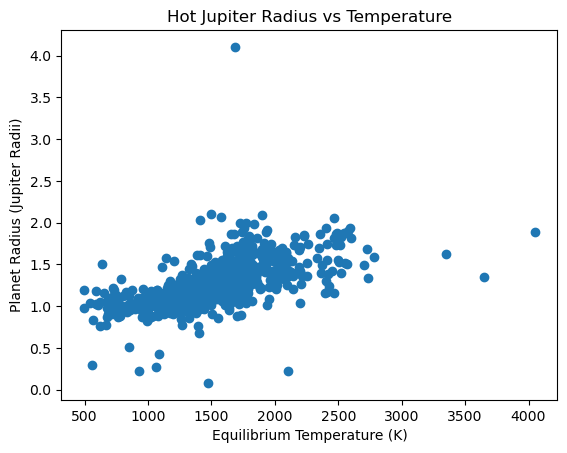

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load the dataset
df = pd.read_csv("PS_2026.03.07_22.43.48.csv",comment="#")

# Step 2: Remove rows with missing values that required
df = df.dropna(subset=['pl_radj', 'pl_bmassj', 'pl_eqt', 'pl_orbper'])

# Step 3: Filter Hot Jupiters
# Conditions:
# mass > 0.36 Jupiter masses, < 11.8
# orbital period < 10 days (Winn et al., 2010)

hot_jupiters = df[(df['pl_bmassj'] > 0.36) & (df['pl_orbper'] < 10) & (df['pl_bmassj'] < 11.8) ]

# Step 4: Print how many planets remain
print("Total planets after cleaning:", len(df))
print("Number of Hot Jupiters:", len(hot_jupiters))

# Step 5: Plot Radius vs Temperature
plt.figure()
plt.scatter(hot_jupiters['pl_eqt'], hot_jupiters['pl_radj'])
plt.xlabel("Equilibrium Temperature (K)")
plt.ylabel("Planet Radius (Jupiter Radii)")
plt.title("Hot Jupiter Radius vs Temperature")

plt.show()

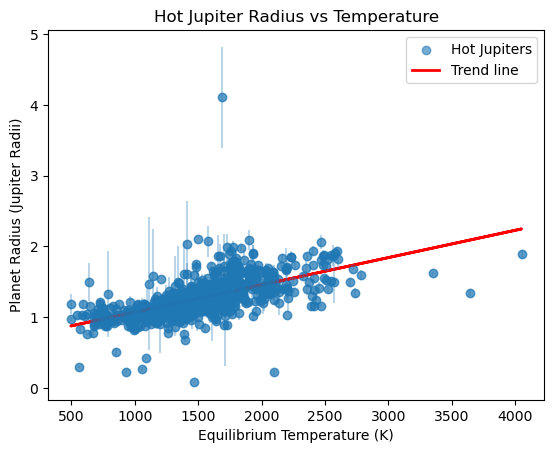

In [2]:
x = hot_jupiters['pl_eqt']
y = hot_jupiters['pl_radj']

# fit line
m, b = np.polyfit(x, y, 1)

trendline = m*x + b

#plt.figure(figsize=(8,6))

plt.scatter(x, y, alpha=0.6, label="Hot Jupiters")

plt.plot(x, trendline, linewidth=2, label="Trend line", color='red')

plt.xlabel("Equilibrium Temperature (K)")
plt.ylabel("Planet Radius (Jupiter Radii)")
plt.title("Hot Jupiter Radius vs Temperature")

plt.legend()
plt.errorbar(hot_jupiters['pl_eqt'], hot_jupiters['pl_radj'], yerr=hot_jupiters['pl_radjerr1'], fmt='o', alpha=0.3)
plt.show()

In [10]:
# Correlation coefficient
corr = np.corrcoef(x, y)[0,1]

print("Correlation coefficient (r) =", corr)

# R^2 value
y_pred = m*x + b
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)

r_squared = 1 - ss_res/ss_tot

print("R^2 =", r_squared)

Correlation coefficient (r) = 0.5912480706082459
R^2 = 0.3495742809979733


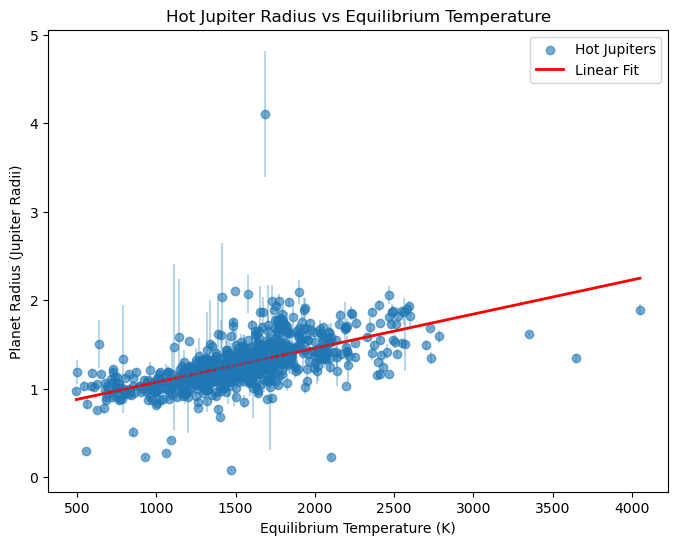

In [8]:
# Sort values for smooth trendline
sorted_idx = np.argsort(x)
x_sorted = x.iloc[sorted_idx]
trend_sorted = (m*x + b).iloc[sorted_idx]

plt.figure(figsize=(8,6))

plt.scatter(x, y, alpha=0.6, label="Hot Jupiters")

plt.plot(x_sorted, trend_sorted, color='red', linewidth=2, label="Linear Fit")

plt.errorbar(hot_jupiters['pl_eqt'], hot_jupiters['pl_radj'], yerr=hot_jupiters['pl_radjerr1'], fmt='none', alpha=0.3)

plt.xlabel("Equilibrium Temperature (K)")
plt.ylabel("Planet Radius (Jupiter Radii)")
plt.title("Hot Jupiter Radius vs Equilibrium Temperature")

plt.legend()
plt.savefig('week 5.png')
plt.show()

In [6]:
print("Number of hot Jupiters in sample:", len(hot_jupiters))

Number of hot Jupiters in sample: 771


In [7]:
inflated = hot_jupiters[hot_jupiters['pl_radj'] > 1.5]

print("Number of highly inflated planets:", len(inflated))

Number of highly inflated planets: 132
